### **Figure 2.** Effects of cross-sectional (A0, left) and longitudinal (dA, right) age on raw (upper) and aperiodic-adjusted (lower) power spectra. 

/home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/results
Main directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data
{'Young': {'min_age': 24.3, 'max_age': 47.6, 'min_age_p5': 35.6, 'max_age_p5': 58.7, 'n_subjects': 45}, 'Middle': {'min_age': 47.8, 'max_age': 63.1, 'min_age_p5': 58.9, 'max_age_p5': 74.5, 'n_subjects': 44}, 'Old': {'min_age': 63.2, 'max_age': 84.1, 'min_age_p5': 70.9, 'max_age_p5': 95.5, 'n_subjects': 44}}
Processing age group: Young, N=45
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Processing phase: p5
  Processing phase: p2
  Pro

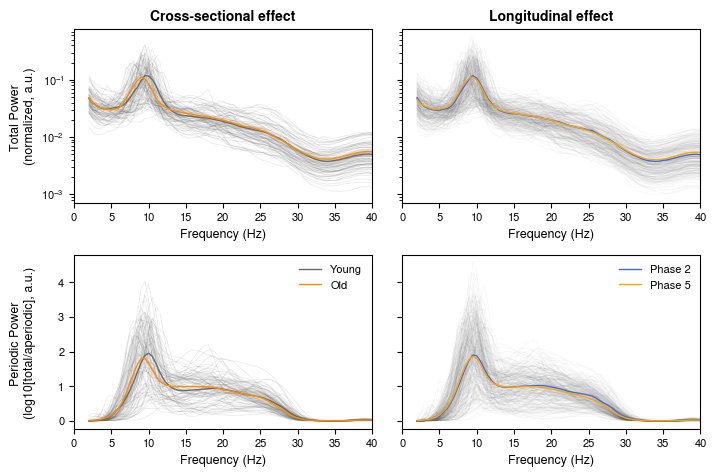

In [1]:
"""
Spectral Power for Cross-Sectional vs. Longitudinal Age Effects (Figure 2)

This notebook aggregates and visualizes MEG Power Spectral Density (PSD) data, 
contrasting the effects of cross-sectional baseline age (A0) against 
longitudinal time elapsed between testing waves (dA). It produces a multi-panel 
publication figure ("Figure 2") comparing raw spectra to aperiodic-corrected curves.

Author: Maité Crespo García
Affiliation: MRC Cognition and Brain Sciences Unit, Cambridge, UK
Date: 2026 (last modified)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print(os.getcwd())
datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Main directory: {datadir}')

pipver = ''
task = 'rest'
phases = ['p2', 'p5']

# ---- File with subjects and arms ----
subjlistfile = os.path.join(datadir,f'meglong_{task}_subjects.tsv')

# ---- File with subjects and age in each phase ----
agefile = os.path.join(datadir,f'meglong_rest_age.tsv')

normalize_psd = True
snorm = '_normalized' if normalize_psd else ''

megtype = 'grad' # 'grad', 'mag',

# --- File containing the average spectra for each age group and phase ---
avgspectrafile = os.path.join(datadir, f'avgspectra_{megtype}{snorm}.tsv')

# --- File containing the aperiodic-corrected (periodic) spectra for each age group and phase ---
avgspectrafile_per = os.path.join(datadir, f'avgspectra_{megtype}_per{snorm}.tsv')


age_groups = ['Young', 'Middle', 'Old']

# --- Read in the subjects and age dataframes ---
subjectsdf = pd.read_csv(subjlistfile, sep='\t', index_col=0)
agedf = pd.read_csv(agefile, sep='\t', index_col=0)
agedf.rename(columns={'p2_meg_age': 'p2_age', 'p5_meg_age': 'p5_age'}, inplace=True)

subjects = subjectsdf.index.tolist()      
agedf = agedf.loc[subjects]
subjectsdf = subjectsdf.loc[subjects]

# --- Define age groups based on age in phase 2 ---
age_bins = np.percentile(agedf['p2_age'], [0, 100/3, 2*100/3, 100])
subjectsdf['Age_group'] = pd.cut(agedf['p2_age'], bins=age_bins, labels=age_groups, include_lowest=True)
agedf.loc[subjects, 'Age_group'] = subjectsdf.loc[subjects, 'Age_group']

# Generate structural summary metrics without using loops
summary_df = agedf.groupby('Age_group', observed=True).agg(
    min_age=('p2_age', 'min'),
    max_age=('p2_age', 'max'),
    min_age_p5=('p5_age', 'min'),
    max_age_p5=('p5_age', 'max'),
    n_subjects=('p2_age', 'count')
)

# Convert directly to a dictionary matching your original schema
age_groups_dict = summary_df.to_dict(orient='index')

print(age_groups_dict)

phases_dict = {
    'p2': {'label': 'Phase 2', 'color': 'royalblue'},
    'p5': {'label': 'Phase 5', 'color': 'orange'}
}

# General figure settings
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.rcParams.update({'font.size': 8}) # setting font size to 8

if normalize_psd:
    chan_units = '(normalized, a.u.)'

# --- Create the figure with 4 subplots ---
fig, axs = plt.subplots(2, 2, figsize=(7.2, 5), gridspec_kw={'wspace': 0.1, 'hspace': 0.3, 'left':0.10, 'right':0.97, 'top':0.91, 'bottom':0.11}, sharey='row')

avgspectra = pd.read_csv(avgspectrafile, sep='\t') # DataFrame with the average spectra for each age group and phase (for the total power spectra, Upper-row plots)
avgspectra.drop(columns=['Freq_1.0Hz', 'Freq_1.5Hz'], inplace=True)
freqs_columns = [col for col in avgspectra.columns if col.startswith('Freq_')]
freqs = np.array([float(col.split('_')[1].split('H')[0]) for col in freqs_columns]) # Extract frequencies from column names

avgspectra_per = pd.read_csv(avgspectrafile_per, sep='\t') # DataFrame with the average spectra for each age group and phase (for the aperiodic-corrected spectra, Lower-row plots)

# Loop over age groups 
for group, group_dict in age_groups_dict.items():

    # Get the list of subjects in the current age group
    group_subjects = agedf[agedf['Age_group'] == group].index.tolist()
    print(f'Processing age group: {group}, N={len(group_subjects)}')

    g = age_groups.index(group) # index of the current group for plotting (0 for Young, 1 for Middle, 2 for Old)

    # loop over subjects
    for id in group_subjects: # just do one subject for now to test
        armx = subjectsdf.loc[id,'arm']

        phases_spectra = [] # This will store the spectrum for each phase for the current subject, to then average across phases for the A0 effect (Left plots)
        phases_spectra_per = [] # This will store the aperiodic-corrected spectrum for each phase for the current subject, to then average across phases for the A0 effect (Left plots)

        # Loop over phases
        for phase in phases:                    
            print(f'  Processing phase: {phase}')

            spectra = avgspectra.loc[(avgspectra['Subject'] == id) & (avgspectra['Phase'] == phase), freqs_columns].values.flatten() # Extract the average spectrum for this subject and phase (for the total power spectra, Upper-row plots)

            spectra_per = avgspectra_per.loc[(avgspectra_per['Subject'] == id) & (avgspectra_per['Phase'] == phase), freqs_columns].values.flatten() # Extract the average aperiodic-corrected spectrum for this subject and phase (for the lower-row plots)
            
            freqs_per = freqs.copy() # Frequencies are the same for total and aperiodic-corrected spectra, so we can just copy them

            # Plot the individual spectra for this subject and phase on the right plots (dA effect), for all groups (Young, Middle, Old)
            # Use more transparency, because there are more individual lines to plot
            ax = axs[0, 1]
            ax.plot(freqs, spectra, color='dimgrey', linewidth=0.5, alpha=0.05)

            ax = axs[1, 1]
            ax.plot(freqs_per, spectra_per, color='dimgrey', linewidth=0.5, alpha=0.05)

            if group in ['Young', 'Old']: # Only append individual spectra for Young and Old groups 
                phases_spectra.append(spectra.copy())
                phases_spectra_per.append(spectra_per.copy())

        # End loop over phases

        if group in ['Young', 'Old']: # Only plot individual spectra for Young and Old groups (Left plots), not for Middle group
            # Now, obtain the average spectra across phases for this subject
            phases_spectra = np.array(phases_spectra) # Convert to numpy array for easier averaging
            phases_spectra_per = np.array(phases_spectra_per) # Convert to numpy array for easier averaging

            phases_mean_spectrum = np.mean(phases_spectra, axis=0) # Average across phases for the A0 effect (Left plots)
            phases_mean_spectrum_per = np.mean(phases_spectra_per, axis=0) # Average across phases for the A0 effect (Left plots)

            # Plot 1 (A0 effect on total power)
            ax = axs[0, 0]
            ax.plot(freqs, phases_mean_spectrum, color='dimgrey', linewidth=0.5, alpha=0.15) 
            
            ax = axs[1, 0]
            ax.plot(freqs_per, phases_mean_spectrum_per, color='dimgrey', linewidth=0.5, alpha=0.15)

avgspectra['Age_group'] = avgspectra['Subject'].map(agedf['Age_group']) # Add the age group information to the avgspectra DataFrame
young_mean = avgspectra.loc[(avgspectra['Age_group'] == 'Young'), freqs_columns].mean().values.flatten() # average across all Young subjects and phases
old_mean = avgspectra.loc[(avgspectra['Age_group'] == 'Old'), freqs_columns].mean().values.flatten() # average across all Old subjects and phases

phase2_mean = avgspectra.loc[(avgspectra['Phase'] == 'p2'), freqs_columns].mean().values.flatten() # average across all subjects and ages for Phase 2
phase5_mean = avgspectra.loc[(avgspectra['Phase'] == 'p5'), freqs_columns].mean().values.flatten() # average across all subjects and ages for Phase 5

avgspectra_per['Age_group'] = avgspectra_per['Subject'].map(agedf['Age_group']) # Add the age group information to the avgspectra_per DataFrame
young_mean_per = avgspectra_per.loc[(avgspectra_per['Age_group'] == 'Young'), freqs_columns].mean().values.flatten() # average across all Young subjects and phases
old_mean_per = avgspectra_per.loc[(avgspectra_per['Age_group'] == 'Old'), freqs_columns].mean().values.flatten() # average across all Old subjects and phases
phase2_mean_per = avgspectra_per.loc[(avgspectra_per['Phase'] == 'p2'), freqs_columns].mean().values.flatten() # average across all subjects and ages for Phase 2
phase5_mean_per = avgspectra_per.loc[(avgspectra_per['Phase'] == 'p5'), freqs_columns].mean().values.flatten() # average across all subjects and ages for Phase 5

# --- Plot 1: Main effect of A0 on total power: just two means, one for Young (averaged across P2 and P5) and one for Old (averaged across P2 and P5)
ax = axs[0, 0]

ax.plot(freqs, young_mean, label='Young', color='dimgrey', linewidth=1, alpha=1)
ax.plot(freqs, old_mean, label='Old', color='darkorange', linewidth=1, alpha=1)
ax.set_yscale('log')
ax.set_title(f'Cross-sectional effect', fontsize=10, fontweight='bold')
ax.set_xlabel('Frequency (Hz)', fontsize=9)
ax.set_ylabel(f'Total Power \n{chan_units}', fontsize=9)
ax.set_xlim(0, 40)

# --- Plot 3: Main effect of A0 on periodic power (log10 ratio of total/aperiodic): just two means, one for Young (averaged across P2 and P5) and one for Old (averaged across P2 and P5)
ax = axs[1, 0]

ax.plot(freqs, young_mean_per, label='Young', color='dimgrey', linewidth=1, alpha=1)
ax.plot(freqs, old_mean_per, label='Old', color='darkorange', linewidth=1, alpha=1)
ax.set_xlabel('Frequency (Hz)', fontsize=9)
ax.set_ylabel(f'Periodic Power \n(log10[total/aperiodic], a.u.)', fontsize=9)
ax.set_xlim(0, 40)

ax.legend(frameon=False, fontsize=8, loc='upper right') # Legend for the A0 effect plots (Left)

# --- Plot 2: Main effect of dA on total power: just two means, one for Phase 2 (averaged across all ages) and one for Phase 5 (averaged across all ages)
ax = axs[0, 1]

ax.plot(freqs, phase2_mean, label='Phase 2', color='royalblue', linewidth=1, alpha=1)
ax.plot(freqs, phase5_mean, label='Phase 5', color='orange', linewidth=1, alpha=1)
ax.set_yscale('log')
ax.set_title(f'Longitudinal effect', fontsize=10, fontweight='bold') #{group
ax.set_xlabel('Frequency (Hz)', fontsize=9)
ax.set_xlim(0, 40)

# --- Plot 4: Main effect of dA on periodic power (log10 ratio of total/aperiodic): just two means, one for Phase 2 (averaged across all ages) and one for Phase 5 (averaged across all ages)
ax = axs[1, 1]

ax.plot(freqs, phase2_mean_per, label='Phase 2', color='royalblue', linewidth=1, alpha=1)
ax.plot(freqs, phase5_mean_per, label='Phase 5', color='orange', linewidth=1, alpha=1)
ax.set_xlabel('Frequency (Hz)', fontsize=9)
ax.set_xlim(0, 40)

ax.legend(frameon=False, fontsize=8, loc='upper right') # Legend for the dA effect plots (Right)

fig.align_ylabels(axs[:,0])

plt.savefig(os.path.join(f'Figure02.png'), dpi=300, format='png', transparent=False)
plt.show()